Интернет-магазин «В один клик» продаёт разные товары: для детей, для дома, мелкую бытовую технику, косметику и даже продукты. Отчёт магазина за прошлый период показал, что активность покупателей начала снижаться. Привлекать новых клиентов уже не так эффективно: о магазине и так знает большая часть целевой аудитории. Возможный выход — удерживать активность постоянных клиентов. 
Нам необходимо  разработать решение, которое позволит персонализировать предложения постоянным клиентам, чтобы увеличить их покупательскую активность.

Руководитель отдела сформировал решение:
1.	Нужно промаркировать уровень финансовой активности постоянных покупателей. В компании принято выделять два уровня активности: «снизилась», если клиент стал покупать меньше товаров, и «прежний уровень».
2.	Нужно собрать данные по клиентам по следующим группам: 
o	Признаки, которые описывают коммуникацию сотрудников компании с клиентом.
o	Признаки, которые описывают продуктовое поведение покупателя. Например, какие товары покупает и как часто.
o	Признаки, которые описывают покупательское поведение клиента. Например, сколько тратил в магазине.
o	Признаки, которые описывают поведение покупателя на сайте. Например, как много страниц просматривает и сколько времени проводит на сайте.

Представим группы признаков (вместе с целевым) в виде диаграммы — такую визуализацию ещё называют диаграммой Исикавы.
 
1.	Нужно построить модель, которая предскажет вероятность снижения покупательской активности клиента в следующие три месяца.
2.	В исследование нужно включить дополнительные данные финансового департамента о прибыльности клиента: какой доход каждый покупатель приносил компании за последние три месяца.
3.	Используя данные модели и данные о прибыльности клиентов, нужно выделить сегменты покупателей и разработать для них персонализированные предложения.

Описание данных:

market_file.csv

Таблица, которая содержит данные о поведении покупателя на сайте, о коммуникациях с покупателем и его продуктовом поведении.
•	id — номер покупателя в корпоративной базе данных.
•	Покупательская активность — рассчитанный класс покупательской активности (целевой признак): «снизилась» или «прежний уровень».
•	Тип сервиса — уровень сервиса, например «премиум» и «стандарт». Зависит от наличия определенной подписки у пользователя.
•	Разрешить сообщать — информация о том, можно ли присылать покупателю дополнительные предложения о товаре. Согласие на это даёт покупатель.
•	Маркет_актив_6_мес — среднемесячное значение маркетинговых коммуникаций компании, которое приходилось на покупателя за последние 6 месяцев. Это значение показывает, какое число рассылок, звонков, показов рекламы и прочего приходилось на клиента.
•	Маркет_актив_тек_мес — количество маркетинговых коммуникаций в текущем месяце.
•	Длительность — значение, которое показывает, сколько дней прошло с момента регистрации покупателя на сайте.
•	Акционные_покупки — среднемесячная доля покупок по акции от общего числа покупок за последние 6 месяцев.
•	Популярная_категория — самая популярная категория товаров у покупателя за последние 6 месяцев.
•	Средний_просмотр_категорий_за_визит — показывает, сколько в среднем категорий покупатель просмотрел за визит в течение последнего месяца.
•	Неоплаченные_продукты_штук_квартал — общее число неоплаченных товаров в корзине за последние 3 месяца.
•	Ошибка_сервиса — число сбоев, которые коснулись покупателя во время посещения сайта за последние 3 месяца.
•	Страниц_за_визит — среднее количество страниц, которые просмотрел покупатель за один визит на сайт за последние 3 месяца.

market_money.csv

Таблица с данными о выручке, которую получает магазин с покупателя, то есть сколько покупатель всего потратил за период взаимодействия с сайтом.
•	id — номер покупателя в корпоративной базе данных.
•	Период — название периода, во время которого зафиксирована выручка. Например, 'текущий_месяц' или 'предыдущий_месяц'.
•	Выручка — сумма выручки за период в условных единицах.

market_time.csv

Таблица с данными о времени (в минутах), которое покупатель провёл на сайте в течение периода.
•	id — номер покупателя в корпоративной базе данных.
•	Период — название периода, во время которого зафиксировано общее время.
•	минут — значение времени, проведённого на сайте, в минутах.

money.csv

Таблица с данными о среднемесячной прибыли продавца за последние 3 месяца: какую прибыль получает магазин от продаж каждому покупателю.
•	id — номер покупателя в корпоративной базе данных.
•	Прибыль — значение прибыли в условных единицах.


Решение задачи будет проходить в два этапа:
1.	Разработаем модель, которая предскажет вероятность снижения покупательской активности.
2.	Выделим сегмент покупателей, проанализируем его и предложим, как увеличить его покупательскую активность. Используем данные моделирования, данные о прибыли покупателей и исходные данные (если понадобятся). 


## Загрузка данных


Загрузим и изучим данные

In [1]:
!pip install scikit-learn --upgrade
!pip install shap -q
!pip -q install phik

In [2]:
import math
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    LabelEncoder,
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder,
    RobustScaler,
    StandardScaler,
)
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

import phik

In [3]:
print('The scikit-learn version is {}.'.format(sklearn.__version__))

The scikit-learn version is 1.6.1.


In [4]:
RANDOM_STATE = 42
TEST_SIZE = 0.25


In [5]:
market_file = pd.read_csv('/datasets/market_file.csv')
market_money = pd.read_csv('/datasets/market_money.csv')
market_time = pd.read_csv('/datasets/market_time.csv')
money = pd.read_csv('/datasets/money.csv', sep=';', decimal=",")

In [6]:
display(market_file.head(10))
market_file.info()

,id,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит
0,215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандартт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
3,215351,Снизилась,стандартт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
4,215352,Снизилась,стандартт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2
5,215353,Снизилась,стандартт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4
6,215354,Снизилась,стандартт,да,5.1,3,431,0.23,Косметика и аксесуары,2,3,7,2
7,215355,Снизилась,стандартт,нет,4.7,4,284,0.17,Товары для детей,5,1,6,4
8,215356,Снизилась,стандартт,да,4.2,4,192,0.14,Косметика и аксесуары,2,2,1,3
9,215357,Снизилась,стандартт,да,3.9,5,154,0.00,Техника для красоты и здоровья,3,3,9,5


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1300 non-null   int64  
 1   Покупательская активность            1300 non-null   object 
 2   Тип сервиса                          1300 non-null   object 
 3   Разрешить сообщать                   1300 non-null   object 
 4   Маркет_актив_6_мес                   1300 non-null   float64
 5   Маркет_актив_тек_мес                 1300 non-null   int64  
 6   Длительность                         1300 non-null   int64  
 7   Акционные_покупки                    1300 non-null   float64
 8   Популярная_категория                 1300 non-null   object 
 9   Средний_просмотр_категорий_за_визит  1300 non-null   int64  
 10  Неоплаченные_продукты_штук_квартал   1300 non-null   int64  
 11  Ошибка_сервиса                

In [7]:
market_file.describe()

,id,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит
count,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300.00000,1300.000000,1300.000000,1300.000000
mean,215997.500000,4.253769,4.011538,601.898462,0.319808,3.27000,2.840000,4.185385,8.176923
std,375.421985,1.014814,0.696868,249.856289,0.249843,1.35535,1.971451,1.955298,3.978126
min,215348.000000,0.900000,3.000000,110.000000,0.000000,1.00000,0.000000,0.000000,1.000000
25%,215672.750000,3.700000,4.000000,405.500000,0.170000,2.00000,1.000000,3.000000,5.000000
50%,215997.500000,4.200000,4.000000,606.000000,0.240000,3.00000,3.000000,4.000000,8.000000
75%,216322.250000,4.900000,4.000000,806.000000,0.300000,4.00000,4.000000,6.000000,11.000000
max,216647.000000,6.600000,5.000000,1079.000000,0.990000,6.00000,10.000000,9.000000,20.000000


In [8]:
display(market_money.head())
market_money.info()

,id,Период,Выручка
0,215348,препредыдущий_месяц,0.0
1,215348,текущий_месяц,3293.1
2,215348,предыдущий_месяц,0.0
3,215349,препредыдущий_месяц,4472.0
4,215349,текущий_месяц,4971.6


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       3900 non-null   int64  
 1   Период   3900 non-null   object 
 2   Выручка  3900 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 91.5+ KB


In [9]:
market_money.describe()

,id,Выручка
count,3900.000000,3900.000000
mean,215997.500000,5025.696051
std,375.325686,1777.704104
min,215348.000000,0.000000
25%,215672.750000,4590.150000
50%,215997.500000,4957.500000
75%,216322.250000,5363.000000
max,216647.000000,106862.200000


Выручка 106 000 т.р. необходимо проверить

In [10]:
display(market_time.head())
market_time.info()

,id,Период,минут
0,215348,текущий_месяц,14
1,215348,предыдцщий_месяц,13
2,215349,текущий_месяц,10
3,215349,предыдцщий_месяц,12
4,215350,текущий_месяц,13


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2600 non-null   int64 
 1   Период  2600 non-null   object
 2   минут   2600 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 61.1+ KB


In [11]:
market_time.describe()

,id,минут
count,2600.000000,2600.000000
mean,215997.500000,13.336154
std,375.349754,4.080198
min,215348.000000,4.000000
25%,215672.750000,10.000000
50%,215997.500000,13.000000
75%,216322.250000,16.000000
max,216647.000000,23.000000


In [12]:
display(money.head())
money.info()

,id,Прибыль
0,215348,0.98
1,215349,4.16
2,215350,3.13
3,215351,4.87
4,215352,4.21


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       1300 non-null   int64  
 1   Прибыль  1300 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 20.4 KB


In [13]:
money.describe()

,id,Прибыль
count,1300.000000,1300.000000
mean,215997.500000,3.996631
std,375.421985,1.013722
min,215348.000000,0.860000
25%,215672.750000,3.300000
50%,215997.500000,4.045000
75%,216322.250000,4.670000
max,216647.000000,7.430000


Вывод
<br>  Данные полные, явных пропусков нет, разные разделители у файлов, точка с запятой и запятая. Выручка похожа на выброс

## Предобработка данных

Сделаем предобработку данных, уберем лишние символы в названиях столбцов, а также сделаем нижний регистр, узнаем кол-во пропусков и дубликатов.

In [14]:
def columns_rename(df):
    df.columns = df.columns.str.replace(' ', '_').str.lower()

In [15]:
columns_rename(market_file)
columns_rename(market_money)
columns_rename(market_time)
columns_rename(money)

In [16]:
print(market_file.columns)

Index(['id', 'покупательская_активность', 'тип_сервиса', 'разрешить_сообщать',
       'маркет_актив_6_мес', 'маркет_актив_тек_мес', 'длительность',
       'акционные_покупки', 'популярная_категория',
       'средний_просмотр_категорий_за_визит',
       'неоплаченные_продукты_штук_квартал', 'ошибка_сервиса',
       'страниц_за_визит'],
      dtype='object')


In [17]:
def prov(list_data):
    for i in list_data:
        print('Количество пропусков в таблицах:', i.isna().sum())

In [18]:
list_data = [market_file, market_money, market_time, money]
prov(list_data)

Количество пропусков в таблицах: id                                     0
покупательская_активность              0
тип_сервиса                            0
разрешить_сообщать                     0
маркет_актив_6_мес                     0
маркет_актив_тек_мес                   0
длительность                           0
акционные_покупки                      0
популярная_категория                   0
средний_просмотр_категорий_за_визит    0
неоплаченные_продукты_штук_квартал     0
ошибка_сервиса                         0
страниц_за_визит                       0
dtype: int64
Количество пропусков в таблицах: id         0
период     0
выручка    0
dtype: int64
Количество пропусков в таблицах: id        0
период    0
минут     0
dtype: int64
Количество пропусков в таблицах: id         0
прибыль    0
dtype: int64


In [19]:
def prov(list_data_2):
    for i in list_data_2:
        print('Количество дубликатов в таблицах:', i.duplicated().sum())

In [20]:
list_data_2 = [market_file, market_money, market_time, money]
prov(list_data)

Количество дубликатов в таблицах: 0
Количество дубликатов в таблицах: 0
Количество дубликатов в таблицах: 0
Количество дубликатов в таблицах: 0


In [21]:
print ('Уникальные значение в таблице market_file:')
for i in ['покупательская_активность', 'тип_сервиса', 'разрешить_сообщать', 'популярная_категория']:
    print (market_file[i].unique())

print('Уникальные значение в таблице market_time:', market_time['период'].unique())
print('Уникальные значение в таблице market_money:', market_money['период'].unique())

Уникальные значение в таблице market_file:
['Снизилась' 'Прежний уровень']
['премиум' 'стандартт' 'стандарт']
['да' 'нет']
['Товары для детей' 'Домашний текстиль' 'Косметика и аксесуары'
 'Техника для красоты и здоровья' 'Кухонная посуда'
 'Мелкая бытовая техника и электроника']
Уникальные значение в таблице market_time: ['текущий_месяц' 'предыдцщий_месяц']
Уникальные значение в таблице market_money: ['препредыдущий_месяц' 'текущий_месяц' 'предыдущий_месяц']


In [22]:
market_file['тип_сервиса'] = market_file['тип_сервиса'].replace('стандартт', 'стандарт')
market_time['период'] = market_time['период'].replace('предыдцщий_месяц', 'предыдущий_месяц')
#market_money['период'] = market_money['период'].replace('препредыдущий_месяц', 'предыдущий_месяц')

Вывод
<br> Переименовали колонки, убрали пробелы.
<br> Сделали нижний регистр в названиях столбцов.
<br> Явных дублей и пропусков не обнаружено.
<br>  В таблицах market_file и market_money заменили неявные дубликаты
<br> Узнали уникальные значения в таблице market_file( категориальные столбцы)


## Исследовательский анализ данных

Проведем исследовательский анализ данных из каждой таблицы. Отберем клиентов с покупательской активностью не менее трёх месяцев, то есть таких, которые что-либо покупали в этот период. 

In [23]:
def hist_box(data, column, hue=None):
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    plt.xlabel(f'Значения столбца {column}')
    plt.ylabel('Частота')
    plt.title(f'Гистограмма для {column}')
    sns.histplot(data=data, x=column, hue=hue, kde=True, element='step', stat='density', common_norm=False)
    plt.subplot(1, 2, 2)
    plt.xlabel(f'Значения столбца {column}')
    plt.title(f'Диаграмма размаха для {column}')
    sns.boxplot(x=data[column])

In [24]:
cat_market = ['покупательская_активность', 'тип_сервиса', 'разрешить_сообщать','популярная_категория']
num_market = ['маркет_актив_6_мес','длительность',
       'акционные_покупки']
market_di = ['маркет_актив_тек_мес','средний_просмотр_категорий_за_визит',
             'неоплаченные_продукты_штук_квартал','ошибка_сервиса', 'страниц_за_визит'  ]


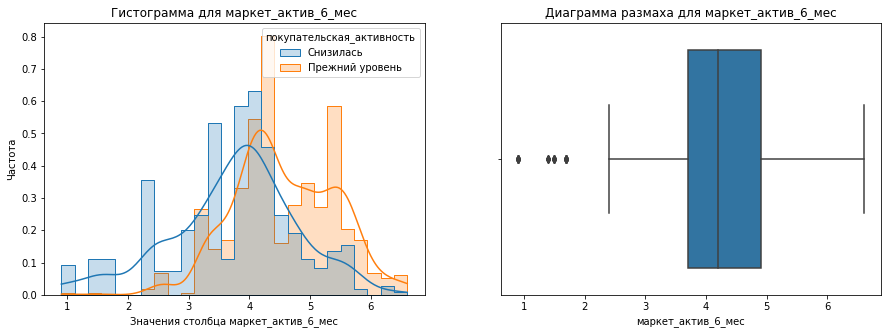

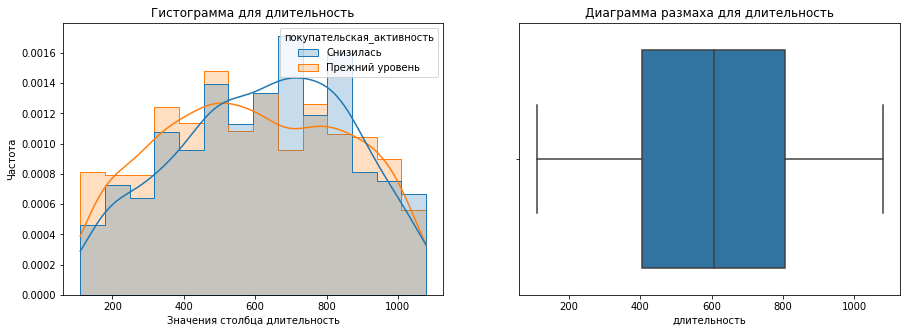

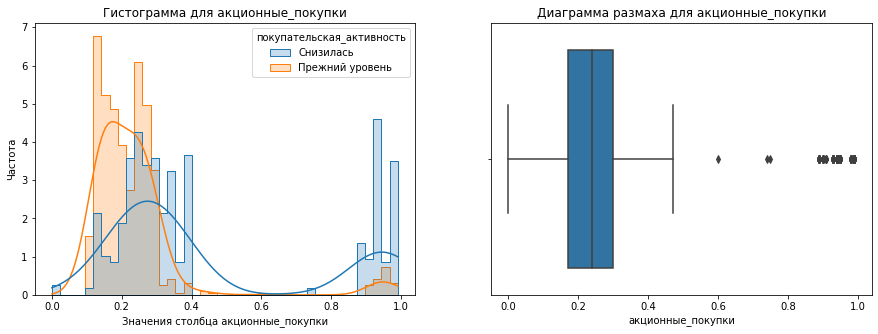

In [25]:
for name in num_market:
    hist_box(market_file, name, hue='покупательская_активность')

In [26]:
def count_di(data, column, hue=None):
    plt.figure(figsize=(15, 4))
    plt.subplot(1, 2, 1)
    plt.xlabel(f'Значения столбца {column}')
    plt.ylabel('Частота')
    plt.title(f'Распределение для {column}')
    sns.countplot(data=data, x=column, hue=hue)

In [27]:
def categorial_unique(df, col):
    display(df[col].unique())
    
    plt.figure(figsize=(8,6))
    plot = sns.countplot(y=col, data=df)
    plot.set_title(f'Рапределение по {col}', fontsize=16)
    plot.set_xlabel('Количество', fontsize=14)

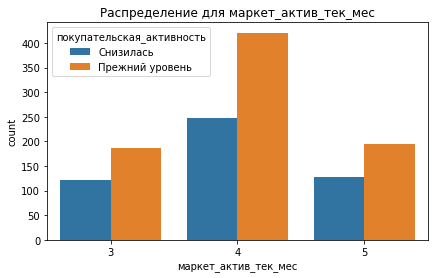

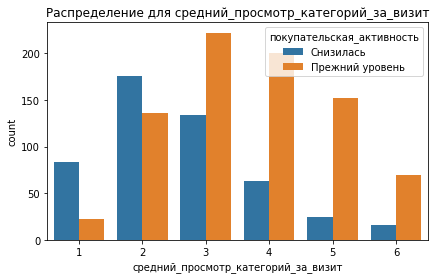

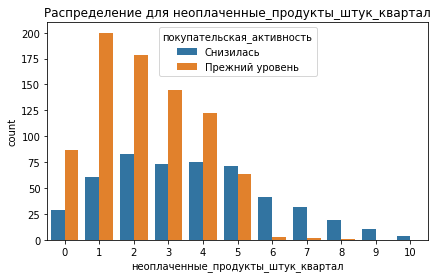

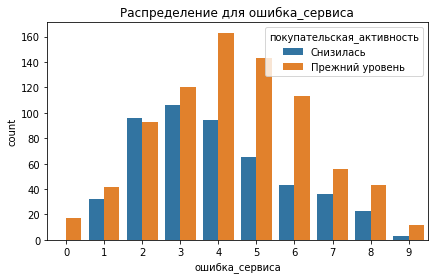

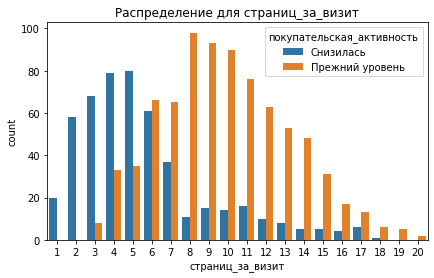

In [28]:
for name in market_di:
    count_di(market_file, name, hue='покупательская_активность')

Вывод:
<br> Маркет_актив_6_мес Нормальное распределение. вбросы на 1 и 2
<br> Маркет_актив_тек_мес Нормальное распределение. имеет только три значения. Возможно стоит перевести в категириальный вид.
<br> Длительность распределено нормально.
<br> Акционные_покупки  Разделилось на две части. Можно сделать категорией покапают по скидке и без.
<br> Средний_просмотр_категорий_за_визит Нормальное распределение. Можно сделать категорией
<br> Неоплаченные_продукты_штук_квартал Можно перевести в категорию
<br> Ошибка_сервиса Нормальное распределение. Можно перевести в категорию.
<br> Страниц_за_визит Нормальное распределение, небольшой скос влево

<div class="alert alert-warning">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> 
    
`Акционные_покупки Разделилось на две части. Можно сделать категорией покапают по скидке и без.` - можно, но нужно ли? У нас цель - аналитика, не стоит лишать себя детальности информации.

<div class="alert alert-warning">
<h2> Комментарий ревьюера  #2 <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> 

Привет! Графики построили, а выводы, кажется, не обновили.
       
</div>


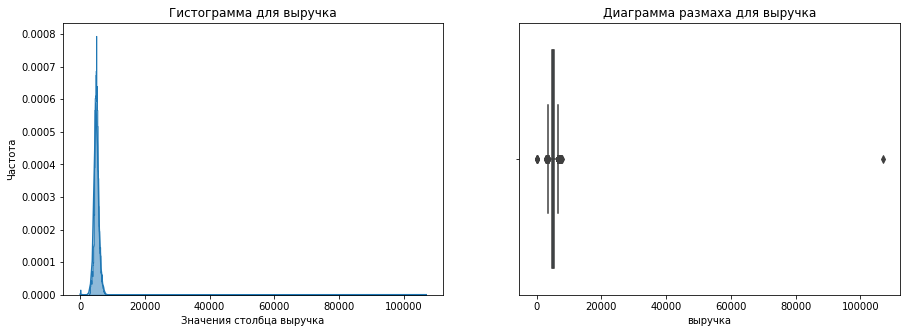

In [29]:
hist_box(market_money, 'выручка')

Выброс выручка 100.000, удалим id покупателя

In [30]:
data = [market_file, market_time, market_money, money]

In [31]:
list_id = market_money.query('выручка > 20000')['id'].tolist()

In [32]:
market_money = market_money[~market_money['id'].isin(list_id)]
market_file = market_file[~market_file['id'].isin(list_id)]
market_time = market_time[~market_time['id'].isin(list_id)]

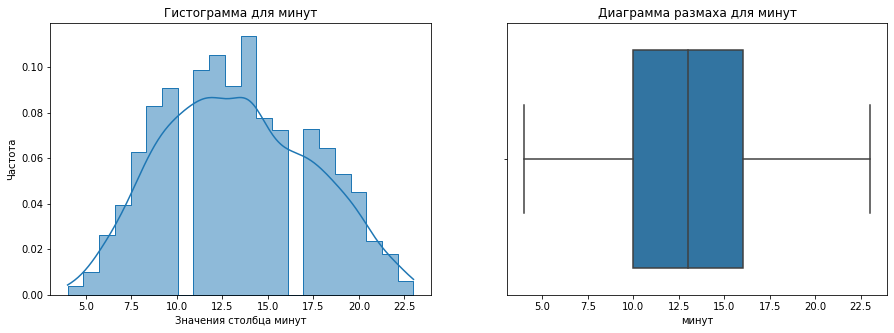

In [33]:
hist_box(market_time, 'минут')

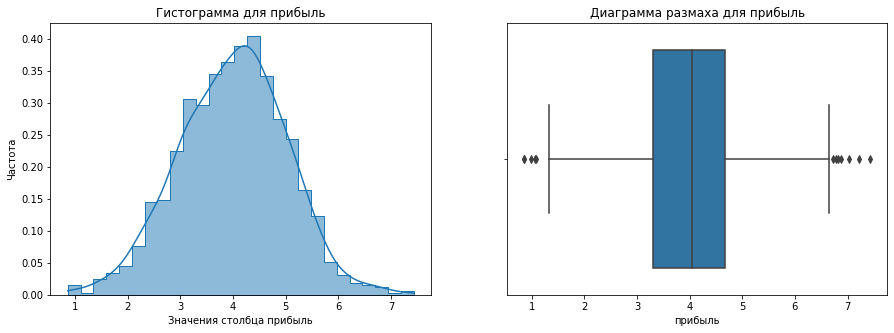

In [34]:
hist_box(money, 'прибыль')

По двум гистограммам: Распеределение нормальное, выбросов нет

In [35]:
def pie_graph(dataset, column, name, n, i):
    plt.subplot(1, n, i)
    plt.title(column)
    plt.pie(x=dataset.groupby(column)[name].count(),
            startangle=90,
            labeldistance=1.1, 
            wedgeprops={'linewidth':3}, 
            autopct='%1.1f%%',
            labels=dataset.groupby(column)[name].count().index)
            

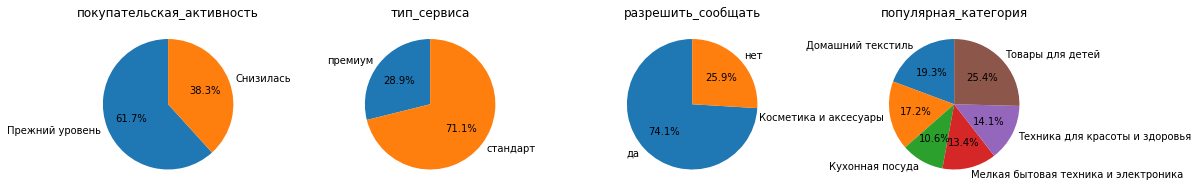

In [36]:
i = 1
plt.figure(figsize=(18,3))
for name in cat_market:
    pie_graph(market_file, name, 'id', len(cat_market), i)
    i += 1

Вывод:
<br>Покупательская_активность почти на 62% на прежнем уровне.
<br>Тип_сервиса  71% стандартный тип.
<br>Разрешить_сообщать 74%  расрешает сообщать.
<br>Популярная_категория товары для детей 25%, далее Домашний текстиль 19%, далее косметика самой популярной являются Товары для детей, далее Домашний текстиль и Косметика 17%

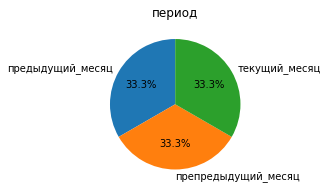

In [37]:
i = 1
plt.figure(figsize=(18,3))
pie_graph(market_money, 'период', 'id', 1, i)

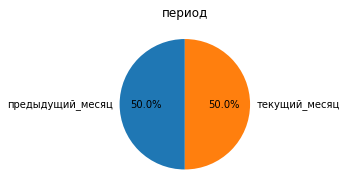

In [38]:
i = 1
plt.figure(figsize=(18,3))
pie_graph(market_time, 'период', 'id', 1, i)

Период распределен равномерно 

In [39]:
list_id = market_money.query('выручка == 0')['id']
print(list_id)

0     215348
2     215348
28    215357
29    215357
34    215359
35    215359
Name: id, dtype: int64


In [40]:
market_money = market_money[~market_money['id'].isin(list_id)]
market_file = market_file[~market_file['id'].isin(list_id)]
market_time = market_time[~market_time['id'].isin(list_id)]

## Объединение таблиц 

In [41]:
market_money2 = pd.pivot_table(market_money, values='выручка', index='id',
                       columns= 'период')
market_money2 = market_money2.reset_index()
market_money2 = market_money2.rename(columns={'предыдущий_месяц':'предыдущий_месяц_выручка', 
                                              'препредыдущий_месяц':'препредыдущий_месяц_выручка', 
                                              'текущий_месяц':'текущий_месяц_выручка'})
display(market_money2.head())
print('market_money2', market_money2.shape[0])

период,id,предыдущий_месяц_выручка,препредыдущий_месяц_выручка,текущий_месяц_выручка
0,215349,5216.0,4472.0,4971.6
1,215350,5457.5,4826.0,5058.4
2,215351,6158.0,4793.0,6610.4
3,215352,5807.5,4594.0,5872.5
4,215353,4738.5,5124.0,5388.5


market_money2 1296


In [42]:
market_time2 = pd.pivot_table(market_time, index='id', values='минут',
                       columns= 'период')
market_time2 = market_time2.reset_index()
market_time2 = market_time2.rename(columns={'предыдущий_месяц':'предыдущий_месяц_минут',
                                            'текущий_месяц':'текущий_месяц_минут'})
display(market_time2.head())
print('market_time2', market_time2.shape[0])

период,id,предыдущий_месяц_минут,текущий_месяц_минут
0,215349,12,10
1,215350,8,13
2,215351,11,13
3,215352,8,11
4,215353,10,10


market_time2 1296


In [43]:
market = pd.merge(market_file, market_money2, on = 'id', how='outer')
market = pd.merge(market, market_time2, on = 'id', how='outer')
display(market.head())
print('market_time2', market.shape[0])

,id,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,предыдущий_месяц_выручка,препредыдущий_месяц_выручка,текущий_месяц_выручка,предыдущий_месяц_минут,текущий_месяц_минут
0,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,5216.0,4472.0,4971.6,12,10
1,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,5457.5,4826.0,5058.4,8,13
2,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,6158.0,4793.0,6610.4,11,13
3,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2,5807.5,4594.0,5872.5,8,11
4,215353,Снизилась,стандарт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4,4738.5,5124.0,5388.5,10,10


market_time2 1296


Объединение выполнено 

## Корреляционный анализ

/opt/conda/lib/python3.9/site-packages/phik/data_quality.py:59: UserWarning: The number of unique values of variable id is large: 1296. Are you sure this is not an interval variable? Analysis for pairs of variables including id can be slow.
  warnings.warn(


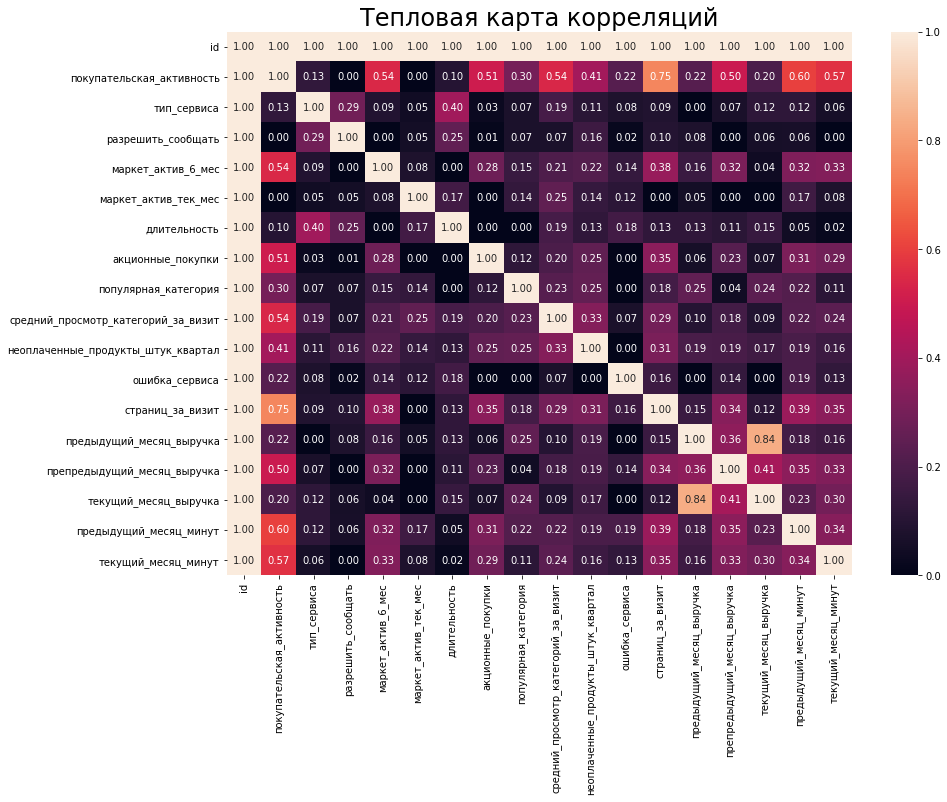

In [44]:
plt.figure(figsize=(14, 10))
phik_matrix = market.phik_matrix(
    interval_cols=[
        'маркет_актив_6_мес',
        'длительность',
        'акционные_покупки',
        'препредыдущий_месяц_выручка',
        'предыдущий_месяц_выручка',
        'текущий_месяц_выручка',
    ]
)
sns.heatmap(phik_matrix, annot=True, fmt='.2f')
plt.title('Тепловая карта корреляций', fontsize=24)
plt.show()

Вывод:
<br>Высокая зависимость между выручкой предпредыдущего месяца и предыдущего.
<br>Высокая зависимость между предыдущий_месяц_минут и препредыдущий_месяц_выручка
<br>Высокая зависимость проведенного врмени на сайте и кол-ом страниц.

Внесла изменения

/opt/conda/lib/python3.9/site-packages/phik/data_quality.py:59: UserWarning: The number of unique values of variable id is large: 1296. Are you sure this is not an interval variable? Analysis for pairs of variables including id can be slow.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/phik/data_quality.py:59: UserWarning: The number of unique values of variable предыдущий_месяц_выручка is large: 1120. Are you sure this is not an interval variable? Analysis for pairs of variables including предыдущий_месяц_выручка can be slow.
  warnings.warn(


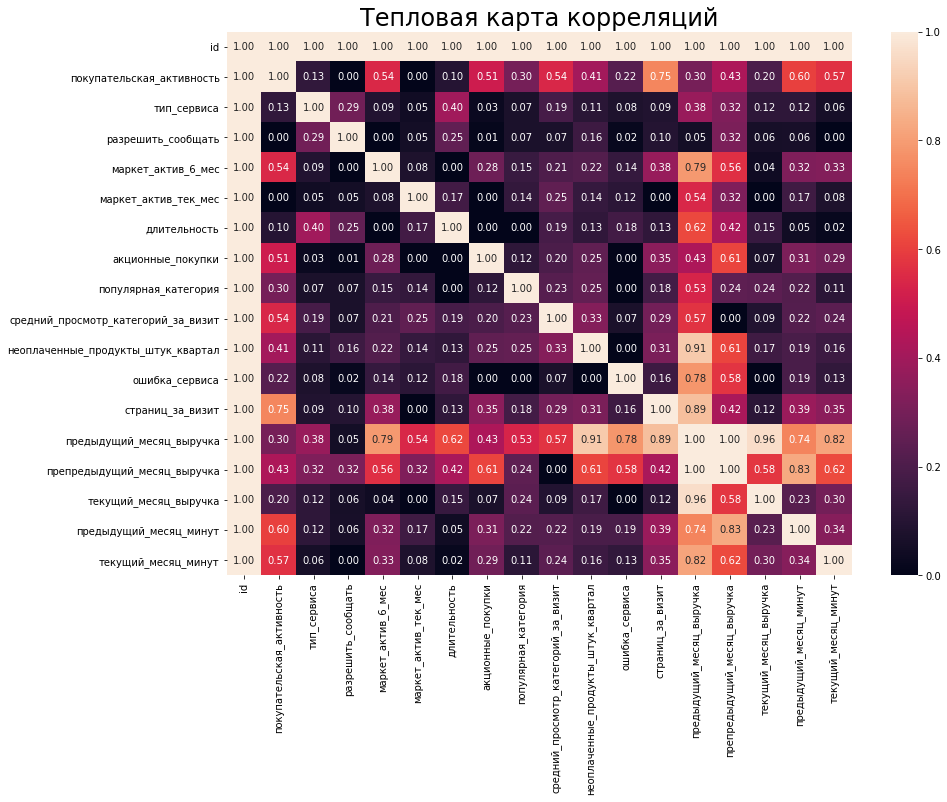

In [46]:
phik_matrix = market.phik_matrix(interval_cols=['маркет_актив_6_мес', 'длительность', 'акционные_покупки', 
                                                   'текущий_месяц_выручка', 'выручка_2_мес'])
plt.figure(figsize=(14, 10))
sns.heatmap(phik_matrix, annot=True, fmt='.2f')
plt.title('Тепловая карта корреляций', fontsize=24)
plt.show()

Высокая корреляция наблюдается между выручкой в предпредыдущем и предыдущем месяцах, а также между выручкой и временем, проведённым на сайте. При этом значения корреляции ниже порога 0.9, поэтому будем считать, что выраженной мультиколлинеарности нет и признаки можно оставить в модели без объединения. Для моделирования это полезно: модель сможет самостоятельно «решить», как использовать информацию из разных периодов, а мы не теряем интерпретируемость динамики выручки.

## Использование пайплайнов

In [47]:
RANDOM_STATE = 42
TEST_SIZE = 0.25

X = market.drop(['покупательская_активность', 'id'], axis=1)
y = market['покупательская_активность']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

In [48]:
#кодирование целевого признака
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

In [49]:
ohe_columns = ['популярная_категория']

In [50]:
print(market.head())

       id покупательская_активность тип_сервиса разрешить_сообщать  \
0  215349                 Снизилась     премиум                 да   
1  215350                 Снизилась    стандарт                нет   
2  215351                 Снизилась    стандарт                 да   
3  215352                 Снизилась    стандарт                нет   
4  215353                 Снизилась    стандарт                 да   

   маркет_актив_6_мес  маркет_актив_тек_мес  длительность  акционные_покупки  \
0                 4.4                     4           819               0.75   
1                 4.9                     3           539               0.14   
2                 3.2                     5           896               0.99   
3                 5.1                     3          1064               0.94   
4                 3.3                     4           762               0.26   

  популярная_категория  средний_просмотр_категорий_за_визит  \
0     Товары для детей             

In [51]:
ord_columns = ['тип_сервиса', 'разрешить_сообщать']
num_columns = [
    'маркет_актив_6_мес',
    'длительность',
    'акционные_покупки',
    'текущий_месяц_выручка',
    'препредыдущий_месяц_выручка',
    'предыдущий_месяц_минут',
    'текущий_месяц_минут',
    'страниц_за_визит',
    'неоплаченные_продукты_штук_квартал',
    'ошибка_сервиса',
    'маркет_актив_тек_мес',
    'средний_просмотр_категорий_за_визит',
] 

In [52]:

ohe_pipe = Pipeline(
    [('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore',  sparse_output=False))
    ]
    )

In [53]:

ord_pipe = Pipeline(
    [('simpleImputer_before_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ord',  OrdinalEncoder(
                categories=[
                    ['стандарт', 'премиум'],
                    ['да', 'нет']], 
                handle_unknown='use_encoded_value', unknown_value=np.nan
            )
        ),
     ('simpleImputer_after_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
    ]
)

In [54]:
data_preprocessor = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(handle_unknown='ignore'), ohe_columns),
        ('ord', OrdinalEncoder(), ord_columns),
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', MinMaxScaler())
        ]), num_columns)
    ],
    remainder='passthrough'
)

In [55]:

pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

Обучение моделей и выбор метрик

In [56]:
param_grid = [
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 5),
        'models__max_features': range(2, 5),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    },
    {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': range(2, 5),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']   
    },
    {
        'models': [LogisticRegression(
            random_state=RANDOM_STATE, 
            solver='liblinear', 
            penalty='l1'
        )],
        'models__C': range(1, 5),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    },
    {
        'models': [SVC(random_state=RANDOM_STATE, kernel='poly', probability=True)],
        'models__degree': range(2, 3),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
    }

]

Нахождение лучшей модели по RandomizedSearchCV

In [57]:
randomized_search = RandomizedSearchCV(
    pipe_final, 
    param_grid, 
    cv=5,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

In [58]:
randomized_search.fit(X_train, y_train);

In [59]:
print('Лучшая модель и её параметры:\n\n', randomized_search.best_estimator_)
print ('Метрика лучшей модели на тренировочной выборке:', randomized_search.best_score_)

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['популярная_категория']),
                                                 ('ord', OrdinalEncoder(),
                                                  ['тип_сервиса',
                                                   'разрешить_сообщать']),
                                                 ('num', MinMaxScaler(),
                                                  ['маркет_актив_6_мес',
                                                   'длительность',
                                                   'акционные_покупки',
                                                   'текущий_месяц_выручка',
                                                   'препредыдущий_месяц_вы

In [60]:
market['покупательская_активность'].unique()

array(['Снизилась', 'Прежний уровень'], dtype=object)

In [61]:

dummy_clf = DummyClassifier(strategy='most_frequent') 
dummy_clf.fit(X_train, y_train)

y_dummy_pred = dummy_clf.predict(X_test)
y_dummy_prob = dummy_clf.predict_proba(X_test)[:, 1] 

dummy_roc_auc = roc_auc_score(y_test, y_dummy_prob)
print(f'ROC-AUC для константной модели: {dummy_roc_auc}')

best_model = randomized_search.best_estimator_  
y_best_pred = best_model.predict(X_test)
y_best_prob = best_model.predict_proba(X_test)[:, 1]

best_roc_auc = roc_auc_score(y_test, y_best_prob)
print(f'ROC-AUC для лучшей модели: {best_roc_auc}')

if best_roc_auc > dummy_roc_auc:
    print("Лучшая модель значительно лучше константной модели.")
else:
    print("Лучшая модель не показала значительного улучшения по сравнению с константной моделью.")

ROC-AUC для константной модели: 0.5
ROC-AUC для лучшей модели: 0.9159487117259232
Лучшая модель значительно лучше константной модели.


Нахождение лучшей модели по GridSearchCV

In [62]:
'''
models — инициализированная модель
param_grid — словарь с гиперпараметрами модели
cv — тип кросс-валидации
scoring — метрика, которую используем для выбора лучшего решения
n_jobs=-1 — подключаем к расчёту ядра процессора
'''


grid = GridSearchCV(
    pipe_final, 
    param_grid=param_grid, 
    cv=5, 
    scoring='roc_auc', 
    n_jobs=-1
)

grid.fit(X_train, y_train)

print('Лучшая модель и её параметры:', grid.best_estimator_)
print ('Метрика лучшей модели:', grid.best_score_)

Лучшая модель и её параметры: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['популярная_категория']),
                                                 ('ord', OrdinalEncoder(),
                                                  ['тип_сервиса',
                                                   'разрешить_сообщать']),
                                                 ('num', StandardScaler(),
                                                  ['маркет_актив_6_мес',
                                                   'длительность',
                                                   'акционные_покупки',
                                                   'текущий_месяц_выручка',
                                                   'препредыдущий_месяц_вы

In [63]:

y_test_prob = randomized_search.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_test_prob)
print(f'Метрика ROC-AUC на тестовой выборке: {roc_auc}')

Метрика ROC-AUC на тестовой выборке: 0.9159487117259232


Вывод: лучшей моделью оказалась LogisticRegression. Значение ROC-AUC около 0.90, полученное на кросс-валидации, показывает, что модель хорошо различает клиентов с высокой и низкой вероятностью снижения активности. При этом на независимой тестовой выборке ROC-AUC ≈ 0.92, что подтверждает устойчивость качества модели и отсутствие явного переобучения.

## Анализ важности признаков

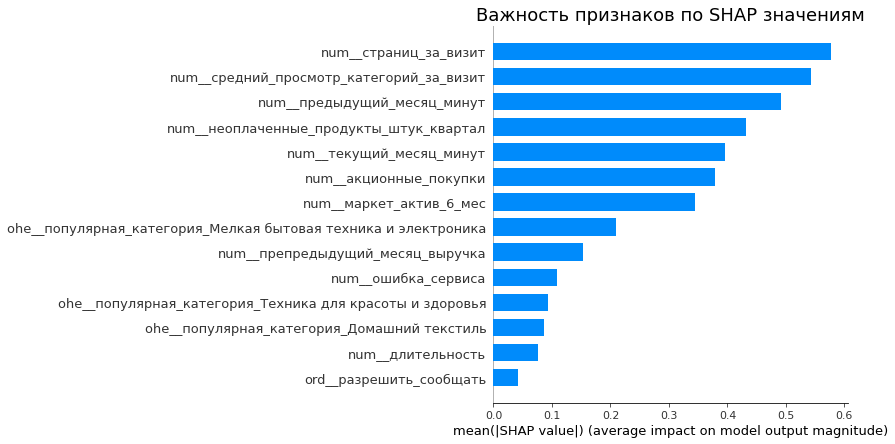

In [64]:
preprocessor = grid.best_estimator_['preprocessor']
model = grid.best_estimator_['models']

X_train_processed = preprocessor.transform(X_train)
feature_names = preprocessor.get_feature_names_out()

explainer = shap.LinearExplainer(model, X_train_processed)
shap_values = explainer.shap_values(X_train_processed)

plt.figure()
shap.summary_plot(
    shap_values,
    features=X_train_processed,
    feature_names=feature_names,
    max_display=14,
    plot_type="bar",
    plot_size=(12, 6),
    show=False,
)
plt.title("Важность признаков по SHAP значениям", fontsize=18)
plt.show()

попытка продолжить код вызывает ошибки

## Сегментация покупателей

In [65]:
# Считаем вероятности снижения активности для ВСЕХ клиентов (а не только для X_test)
X_all = market.drop(['покупательская_активность', 'id'], axis=1)
proba_all = grid.predict_proba(X_all)[:, 1]

# Собираем единый датасет для анализа сегмента
# (сохраняем id, таргет, признаки, вероятность и прибыль)
df = market[['id', 'покупательская_активность']].copy()
df = pd.concat([df.reset_index(drop=True), X_all.reset_index(drop=True)], axis=1)
df['вероятность'] = proba_all

# Добавляем прибыль из таблицы money
# (в `money` уже приведены названия столбцов к нижнему регистру)
df = df.merge(money, on='id', how='left')

df.sort_values(by='вероятность', ascending=False).head()

,id,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,предыдущий_месяц_выручка,препредыдущий_месяц_выручка,текущий_месяц_выручка,предыдущий_месяц_минут,текущий_месяц_минут,вероятность,прибыль
200,215552,Снизилась,стандарт,да,0.9,4,624,0.89,Косметика и аксесуары,1,9,5,1,5678.5,4726.0,6194.6,12,11,0.998977,4.33
349,215701,Снизилась,стандарт,да,0.9,4,212,0.95,Домашний текстиль,2,5,4,2,4685.5,4444.0,5161.3,9,7,0.998686,5.05
186,215538,Снизилась,премиум,да,1.5,5,788,0.89,Товары для детей,1,4,4,4,6013.5,4641.0,6900.1,8,4,0.998132,2.79
316,215668,Снизилась,премиум,да,4.4,4,343,0.94,Товары для детей,2,9,2,2,5567.5,4723.0,5293.2,6,9,0.997449,4.49
353,215705,Снизилась,премиум,нет,0.9,4,657,0.99,Домашний текстиль,2,4,2,5,5055.5,4568.0,5522.2,10,7,0.997250,4.30


In [66]:
# `df` уже содержит прибыль после merge в предыдущей ячейке
# Оставим эту ячейку как «no-op», чтобы не ломать последовательность выполнения
_ = df.shape

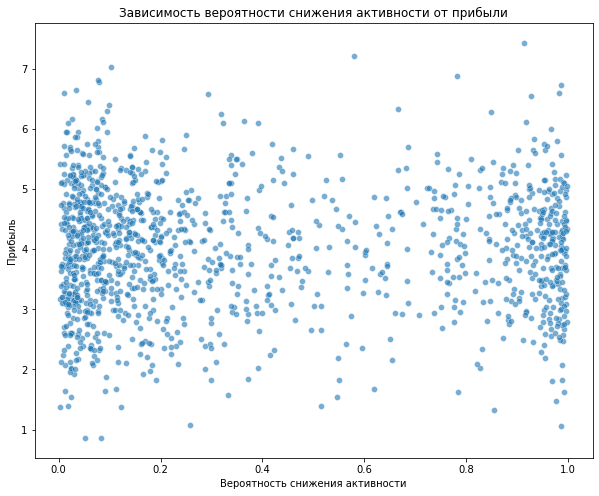

In [67]:
fig = plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, y='прибыль', x='вероятность', alpha=0.6)
plt.xlabel('Вероятность снижения активности')
plt.ylabel('Прибыль')
plt.title('Зависимость вероятности снижения активности от прибыли')
plt.show()

Явной линейной зависимости между вероятностью снижения активности и прибылью не наблюдается.

Это ожидаемо: прибыль — это скорее показатель «ценности» клиента для бизнеса, а вероятность — показатель «риска». Эти величины не обязаны расти/падать синхронно. Поэтому сегментацию будем строить как пересечение **высокого риска** и **высокой (или хотя бы не низкой) прибыли**.

In [68]:
def build_scatterplots(cat_columns):
    for cat_col in cat_columns:
        fig = plt.figure(figsize=(10,8))
        sns.scatterplot(data=df, y='прибыль', x='вероятность', hue=cat_col)
        plt.xlabel('Вероятность снижения активности')
        plt.ylabel('Прибыль')
        plt.title('Зависимость вероятности снижения активности от выручки')
        plt.show()

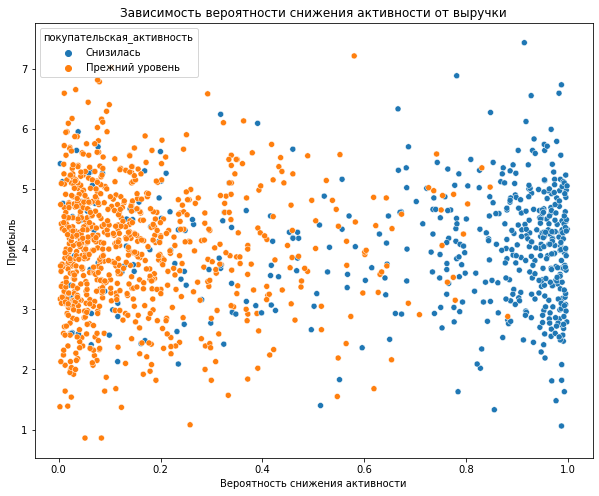

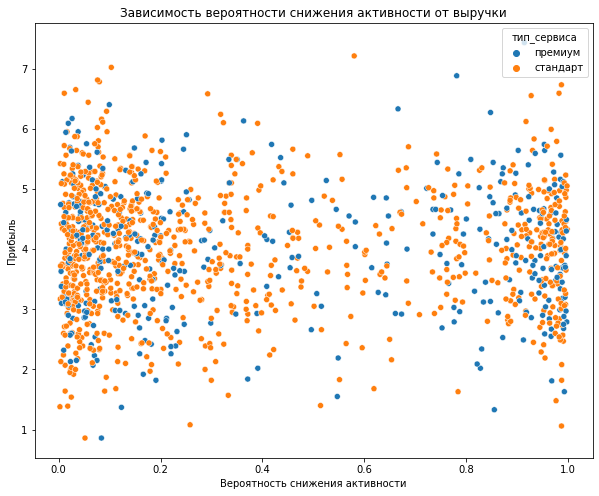

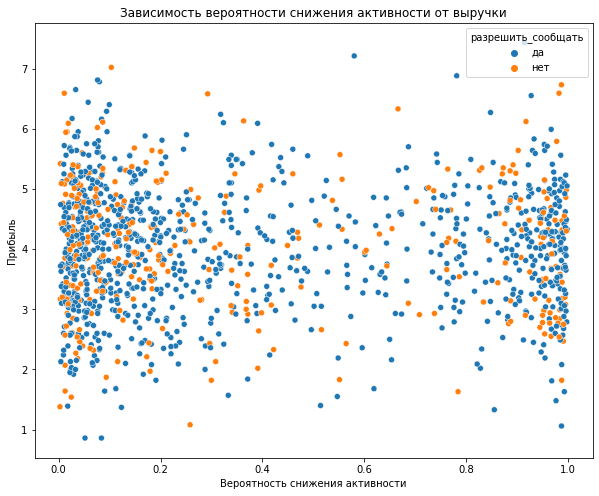

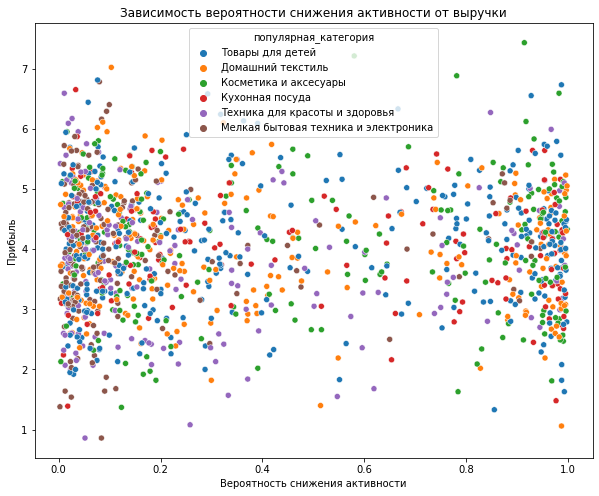

In [69]:
cat_columns = list(df.select_dtypes(include='object').columns)
build_scatterplots(cat_columns)

In [70]:
def histogram(df, col, target):
    plt.figure(figsize=(8,6))
    plot = sns.histplot(df, bins=20, kde=True, hue=target, x=col)
    plot.set_title(f'Рапределение по {col}', fontsize=16)
    plot.set_ylabel('Количество', fontsize=14)
    
    
def categoral_unique(df, col):
    display(df[col].unique())
    
    plt.figure(figsize=(8,6))
    plot = sns.countplot(y=col, data=df)
    plot.set_title(f'Рапределение по {col}', fontsize=16)
    plot.set_xlabel('Количество', fontsize=14)

In [71]:
cat_columns = list(df.select_dtypes(include='object').columns)
di_columns = market_di
num_columns = [
    'маркет_актив_6_мес',
    'длительность',
    'акционные_покупки',
    'текущий_месяц_выручка',
    'препредыдущий_месяц_выручка',
    'прибыль',
]

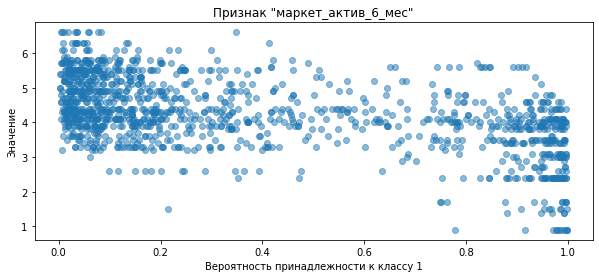

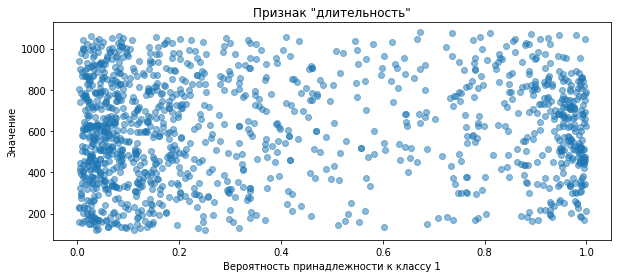

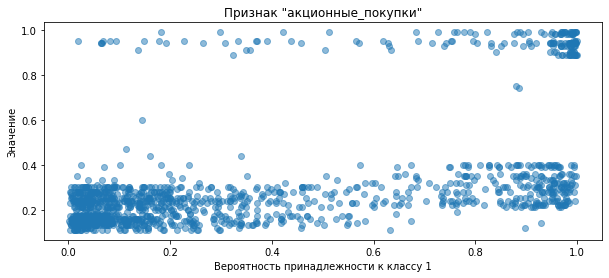

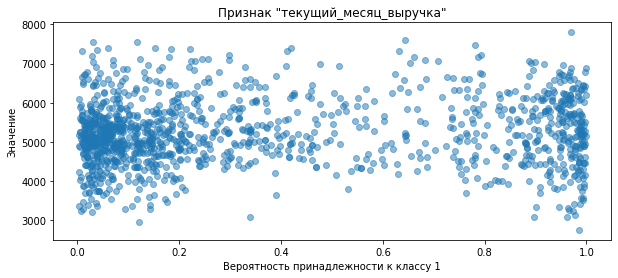

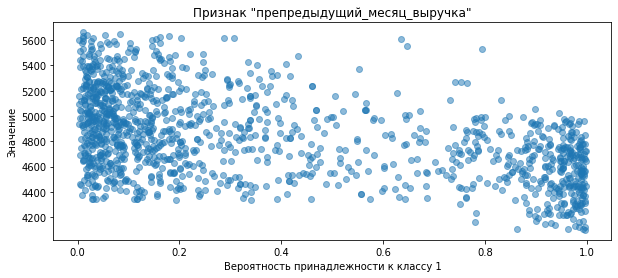

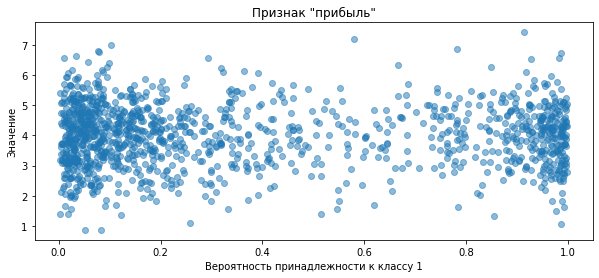

In [72]:
 
for name in num_columns:
    plt.figure(figsize=(10, 4))
    plt.title(f'Признак "{name}"')
    plt.xlabel('Вероятность принадлежности к классу 1')
    plt.ylabel(f'Значение')
    plt.scatter(x=df['вероятность'], 
                y=df[name],
                alpha=0.5)

На основе приведённых графиков можно определить определённые пороговые значения признаков для классификации покупателей. Так, покупатели с низкой активностью демонстрируют следующие показатели:

<br>маркет_актив_6_мес менее 3;
<br>акционные покупки выше 0.6;
<br>средний просмотрт категорий_за_визит менее 3;
<br>неоплачено_штук более 5;
<br>страницы за визит менее 7;
<br>минуты_пред ниже 14;
<br>минуты_тек ниже 14. 
<br>Можно выделить сегмент покупателей, которые покупают в основном акционные товары, то есть со значениями признака Акционные покупки более 0.6, поскольку активность таких покупателей снизилась на последнее время
Для остальных признаков трудно установить чёткие пороги.

Выделение сегмента на основе вероятности и прибыли

Наша цель — получить **репрезентативный** (≥ 100 наблюдений) и **бизнес-значимый** сегмент, поэтому ниже зададим пороги по квантилям и проверим размер сегмента.

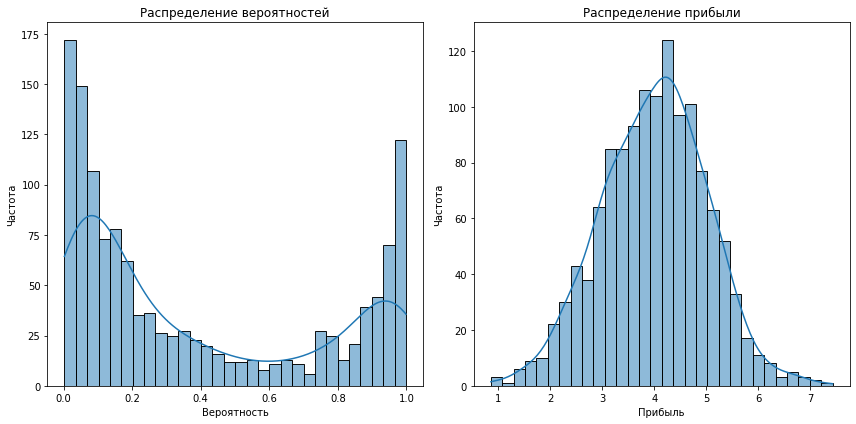

In [73]:
# 1. Исследование распределения
plt.figure(figsize=(12, 6))

# Гистограмма вероятностей
plt.subplot(1, 2, 1)
sns.histplot(df['вероятность'], bins=30, kde=True)
plt.title('Распределение вероятностей')
plt.xlabel('Вероятность')
plt.ylabel('Частота')

# Гистограмма прибыли
plt.subplot(1, 2, 2)
sns.histplot(df['прибыль'], bins=30, kde=True)
plt.title('Распределение прибыли')
plt.xlabel('Прибыль')
plt.ylabel('Частота')

plt.tight_layout()
plt.show()

In [74]:
# Подбираем пороги так, чтобы сегмент был >= 100 наблюдений.
# Выбираем верхние 30% по риску (вероятности) и верхние 50% по прибыли.
prob_threshold = df['вероятность'].quantile(0.70)
profit_threshold = df['прибыль'].quantile(0.50)

prob_threshold, profit_threshold

(0.6417397830983599, 4.045)

In [75]:
segment = df[(df['вероятность'] >= prob_threshold) & (df['прибыль'] >= profit_threshold)].copy()

print('Размер сегмента:', segment.shape[0])
print('Доля сегмента:', round(segment.shape[0] / df.shape[0], 3))

Размер сегмента: 204
Доля сегмента: 0.157


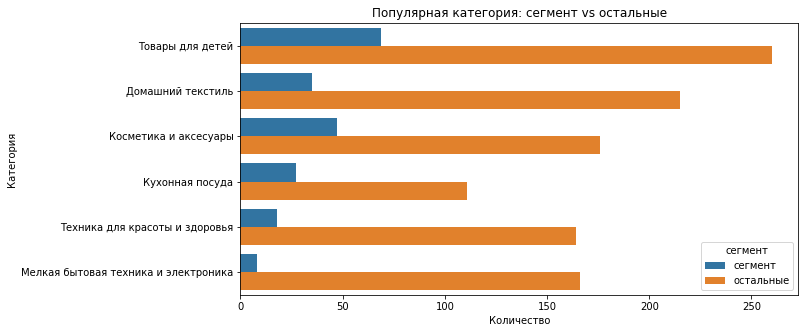

In [76]:
# Сравним распределение популярной категории в сегменте и вне сегмента
seg_df = df.copy()
seg_df['сегмент'] = (seg_df['id'].isin(segment['id'])).map({True: 'сегмент', False: 'остальные'})

plt.figure(figsize=(10, 5))
sns.countplot(data=seg_df, y='популярная_категория', hue='сегмент')
plt.title('Популярная категория: сегмент vs остальные')
plt.xlabel('Количество')
plt.ylabel('Категория')
plt.show()

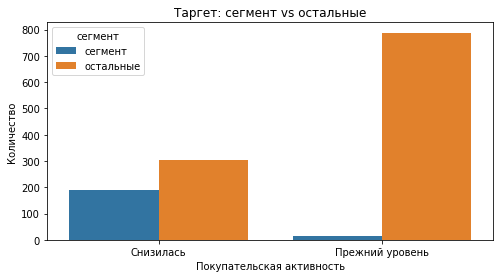

In [77]:
# Сравним долю классов таргета в сегменте и вне сегмента
plt.figure(figsize=(8, 4))
sns.countplot(data=seg_df, x='покупательская_активность', hue='сегмент')
plt.title('Таргет: сегмент vs остальные')
plt.xlabel('Покупательская активность')
plt.ylabel('Количество')
plt.show()

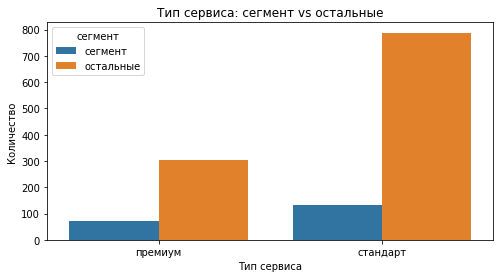

In [78]:
plt.figure(figsize=(8, 4))
sns.countplot(data=seg_df, x='тип_сервиса', hue='сегмент')
plt.title('Тип сервиса: сегмент vs остальные')
plt.xlabel('Тип сервиса')
plt.ylabel('Количество')
plt.show()

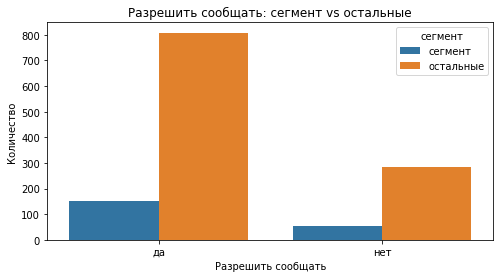

In [79]:
plt.figure(figsize=(8, 4))
sns.countplot(data=seg_df, x='разрешить_сообщать', hue='сегмент')
plt.title('Разрешить сообщать: сегмент vs остальные')
plt.xlabel('Разрешить сообщать')
plt.ylabel('Количество')
plt.show()

In [80]:
continuous_values = [
    'маркет_актив_6_мес',
    'длительность',
    'акционные_покупки',
    'текущий_месяц_выручка',
    'препредыдущий_месяц_выручка',
    'предыдущий_месяц_минут',
    'текущий_месяц_минут',
]

In [81]:
def continuous(columns):
    # Сравниваем распределения непрерывных признаков: сегмент vs остальные
    for col in columns:
        plt.figure(figsize=(10, 4))
        sns.histplot(
            data=seg_df,
            x=col,
            hue='сегмент',
            bins=30,
            stat='density',
            common_norm=False,
            kde=True,
        )
        plt.title(f'Распределение {col}: сегмент vs остальные')
        plt.xlabel(col)
        plt.ylabel('Плотность')
        plt.show()

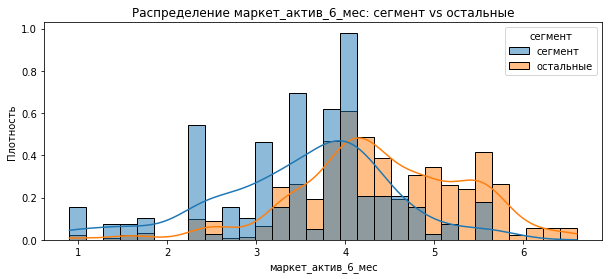

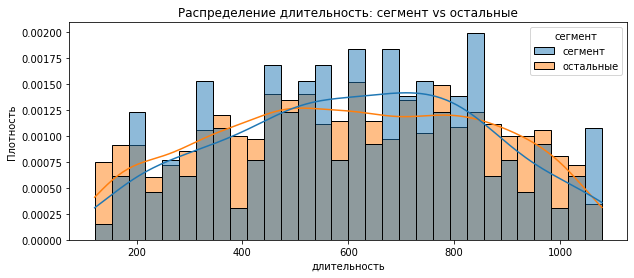

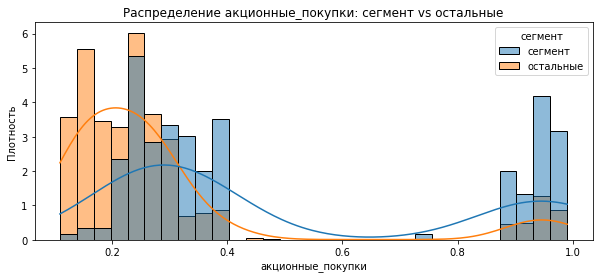

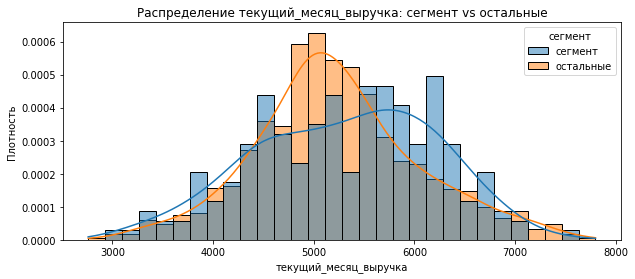

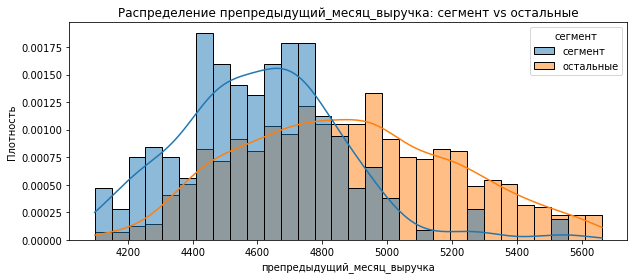

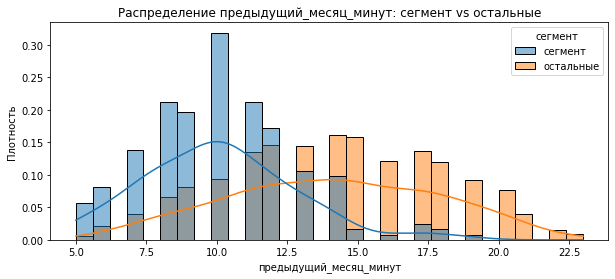

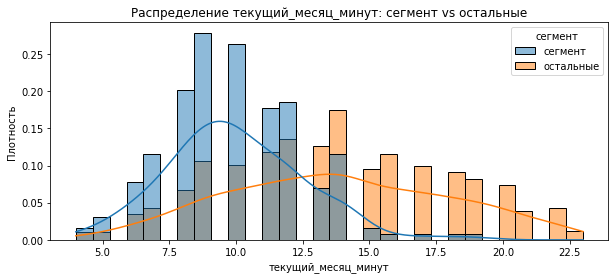

In [82]:
continuous(continuous_values)

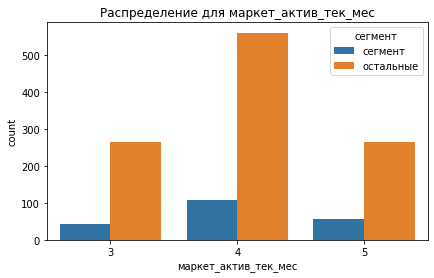

In [83]:
# Для дискретных признаков также сравним сегмент vs остальные
count_di(seg_df, market_di[0], hue='сегмент')

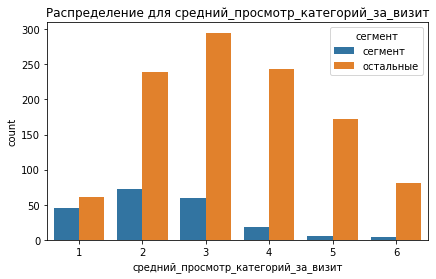

In [84]:
count_di(seg_df, market_di[1], hue='сегмент')

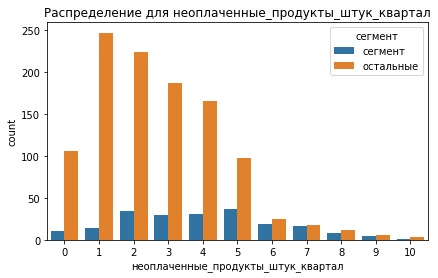

In [85]:
count_di(seg_df, market_di[2], hue='сегмент')

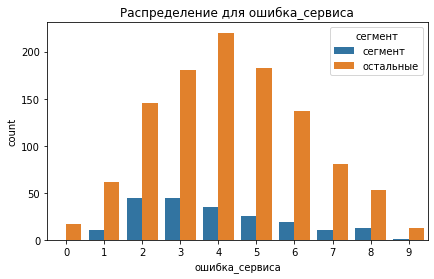

In [86]:
count_di(seg_df, market_di[3], hue='сегмент')

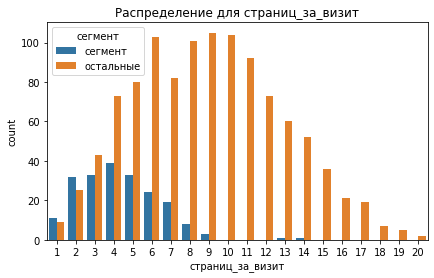

In [87]:
count_di(seg_df, market_di[4], hue='сегмент')

## Общий вывод

Общий вывод

Цель проекта — построить модель, которая предсказывает вероятность снижения покупательской активности клиентов интернет-магазина «В один клик», и на основе анализа данных предложить рекомендации по удержанию клиентов.

### Подготовка данных

- Данные загружены из 4 таблиц: поведение/коммуникации/продуктовое поведение (`market_file`), выручка по периодам (`market_money`), время на сайте по периодам (`market_time`), прибыль (`money`).
- Проведена предобработка: приведены названия столбцов к единому формату, исправлены опечатки/неявные дубликаты в категориях, учтены разные разделители.
- Выброс по выручке и нулевые выручки обработаны фильтрацией соответствующих клиентов.

### Исследовательский анализ (в разрезе таргета)

EDA выполнен в разрезе целевого признака `покупательская_активность` (через наложение распределений). Сформирован портрет клиента со снижающейся активностью: такие клиенты в среднем меньше проводят времени на сайте, просматривают меньше страниц/категорий, чаще сталкиваются с ошибками сервиса и в большей степени ориентированы на акционные покупки. Эти наблюдения стали «костяком» бизнес-выводов.

### Модель и качество

- Для обучения использован пайплайн с кодированием категориальных признаков и масштабированием числовых.
- Перебраны модели (DecisionTree, KNN, LogisticRegression, SVC), лучшей оказалась **LogisticRegression**.
- В качестве основной метрики выбрана **ROC-AUC**, так как классы не сбалансированы и для бизнеса важно качество ранжирования вероятностей без фиксации порога.
- ROC-AUC на кросс-валидации около 0.90, на тестовой выборке около 0.92, что говорит о хорошем качестве и устойчивости.

### Важность признаков (SHAP)

SHAP-анализ показал, что наиболее важны признаки, связанные с вовлечённостью на сайте (время/страницы), выручкой по периодам, маркетинговой активностью и техническими ошибками. Это согласуется с результатами EDA и помогает определить приоритеты воздействия: стабильность сервиса, UX/навигация и более релевантные коммуникации.

### Сегментация и рекомендации

Сегмент сформирован как пересечение клиентов с **высоким риском** (верхние 30% по вероятности) и **прибылью не ниже медианы**, чтобы сегмент был одновременно репрезентативным (≥100 наблюдений) и бизнес-значимым.

По сравнению «сегмент vs остальные» сегмент характеризуется меньшей вовлечённостью на сайте и большей промо-чувствительностью, а также (в зависимости от распределений) может иметь повышенные значения по ошибкам сервиса и неоплаченным товарам.

Рекомендации:

- Персональные предложения/купоны для промо-чувствительных клиентов (с контролем частоты коммуникаций).
- Улучшение UX/навигации для ускорения поиска товара (подборки, рекомендации, упрощение пути до покупки).
- Приоритетное устранение ошибок сервиса и улучшение воронки оплаты; триггерные напоминания по брошенной корзине.

Итог: модель обеспечивает качественное ранжирование по риску снижения активности, а EDA + SHAP + сегментация дают понятный список точек воздействия для удержания наиболее ценных клиентов.